<a href="https://colab.research.google.com/github/preesr/quantum-computing/blob/main/Quantum_Experiment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install 'qiskit[visualization]' qiskit-ibm-runtime qiskit-aer
# Core Qiskit imports
from qiskit import QuantumCircuit # Need this to build quantum programs, define qubits, and perform operations
from qiskit.visualization import plot_histogram
from qiskit_aer import AerSimulator
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager # for optimizing the hardware

# IBM Runtime specific imports
from qiskit_ibm_runtime import SamplerV2 as Sampler, QiskitRuntimeService #ibm runtime service in IBM cloud

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 13.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 65.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 412.6/412.6 kB 30.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 120.7/120.7 kB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.7/94.7 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.8/9.8 MB 65.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 72.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 224.2/224.2 kB 14.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.6/76.6 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.2/130.2 kB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 541.5/5

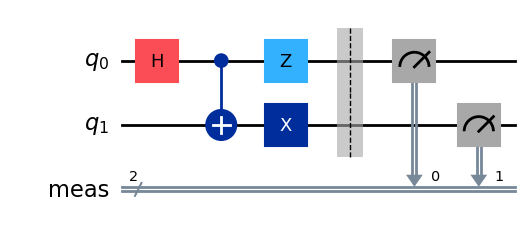

In [ ]:
# Import IBM Quantum primitives
from qiskit import QuantumCircuit

# Make state
qc = QuantumCircuit(2)
qc.h(0)
qc.cx(0, 1)
qc.x(1)
qc.z(0)

# Measure state
qc.measure_all()

# Draw circuit
qc.draw("mpl")

In [ ]:
# Load IBM Quantum Compute Service
from qiskit_ibm_runtime import QiskitRuntimeService

## Load IBM Quantum Compute Service
QiskitRuntimeService.save_account(
    channel="ibm_quantum_platform",
    token="",
    overwrite=True,
    set_as_default=True,
 )
service = QiskitRuntimeService(channel="ibm_quantum_platform")


# Or load saved credentials
service = QiskitRuntimeService()

# Use the least busy backend, or uncomment the loading of a specific backend like "ibm_brisbane".
backend = service.least_busy(operational=True, simulator=False, min_num_qubits=127)
# backend = service.backend("ibm_brisbane")
print(backend.name)

qiskit_runtime_service.__init__:WARNING:2026-08-17 04:42:23,794: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService(). Alternatively, pass instance='auto' or save it to your account for auto-selection without warning.
qiskit_runtime_service.__init__:WARNING:2026-08-17 04:42:26,548: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default insta

ibm_kingston


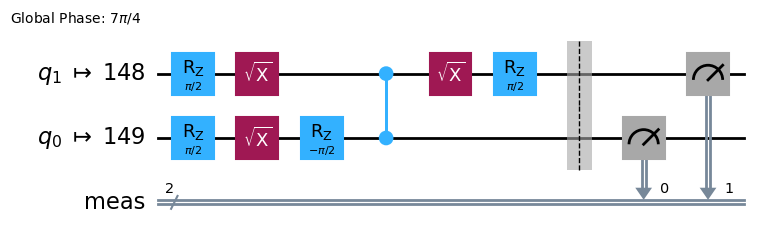

In [ ]:
# Transpile the circuit and optimize for running on the quantum computer selected
# Step 2: Transpile
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

target = backend.target
pm = generate_preset_pass_manager(target=target, optimization_level=3)
qc_isa = pm.run(qc)

qc_isa.draw("mpl")

In [ ]:
# Load the Runtime primitive and session
from qiskit_ibm_runtime import SamplerV2 as Sampler

sampler = Sampler(mode=backend)

In [ ]:
## Load the backend sampler
from qiskit.primitives import BackendSamplerV2

## Load the Aer simulator and generate a noise model based on the currently-selected backend.
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel

noise_model = NoiseModel.from_backend(backend)

## Define a simulator using Aer, and use it in Sampler.
backend_sim = AerSimulator(noise_model=noise_model)
sampler_sim = BackendSamplerV2(backend=backend_sim)

## Alternatively, load a fake backend with generic properties and define a simulator.
## backend_gen = GenericBackendV2(num_qubits=18)
## sampler_gen = BackendSamplerV2(backend=backend_gen)

In [11]:
#job = sampler.run([qc_isa], shots=100)
job = sampler_sim.run([qc_isa]) # uncomment if you want to run on a simulator
res = job.result()
counts = res[0].data.meas.get_counts()

counts =  {'01': 495, '10': 518, '11': 6, '00': 5}


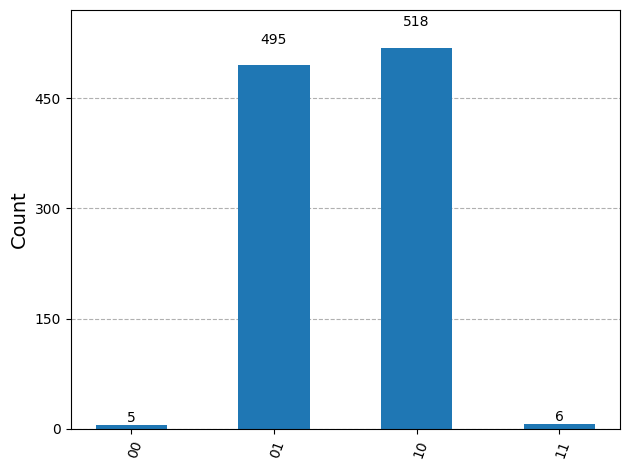

In [12]:
from qiskit.visualization import plot_histogram

print("counts = ", counts)
plot_histogram(counts)